In [118]:
import numpy as np
from astropy.io import fits # You might need to pip install this
import pylab as plt # only needed for verification
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

import torch.nn.functional as F
import torch.nn as nn
from torch.autograd import Variable

print(torch.__version__)

2.10.0


In [2]:
path_labels = "./labels.fits"
allstar = fits.open(path_labels)

(5.0, 0.0)

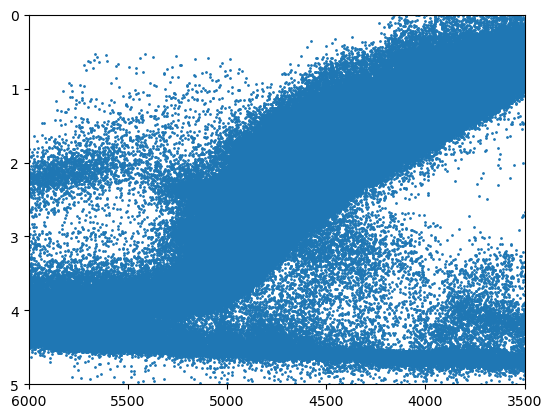

In [3]:
# the labels are in an enormous table in element [1] of this FITS file
labels = allstar[1].data
plt.scatter(labels['TEFF'], labels['LOGG'], s=1)
plt.xlim(6000, 3500)
plt.ylim(5, 0)

In [4]:
# make a reasonable red-giant-branch sample
RGB = True
RGB = np.logical_and(RGB, labels['TEFF'] > 3500.)
RGB = np.logical_and(RGB, labels['TEFF'] < 5400.)
RGB = np.logical_and(RGB, labels['LOGG'] < 3.0)
RGB = np.logical_and(RGB, labels['LOGG'] > 0.0)
RGB = np.logical_and(RGB, labels['H'] < 10.5)
print(np.sum(RGB))

145991


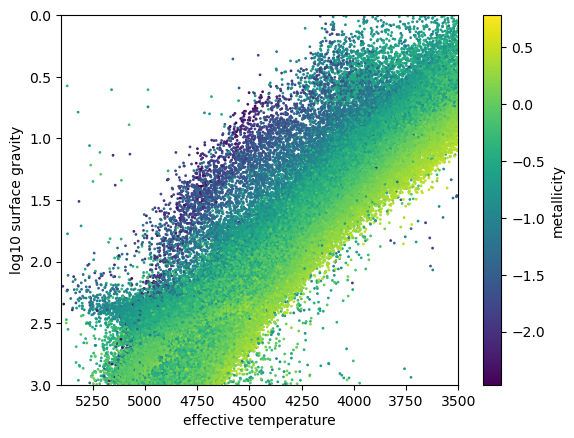

In [5]:
# make a plot that an astronomer likes to see
RGB_labels = labels[RGB]
plt.scatter(RGB_labels['TEFF'], RGB_labels['LOGG'], c=RGB_labels['FE_H'], s=1)
plt.xlim(5400, 3500)
plt.xlabel("effective temperature")
plt.ylim(3., 0.)
plt.ylabel("log10 surface gravity")
plt.colorbar(label="metallicity")

In [106]:
# make train, validation, and test data sets
rng = np.random.default_rng(7)
N_RGB = len(RGB_labels)
N_train, N_valid, N_test = 1024, 256, 512
I = rng.permutation(N_RGB)
I_train = I[0:N_train]
I_valid = I[N_train:N_train+N_valid]
I_test = I[N_train+N_valid:N_train+N_valid+N_test]

train_labels = RGB_labels[I_train]
train_labels = np.float32(train_labels["LOGG"])
valid_labels = RGB_labels[I_valid]
test_labels = RGB_labels[I_test]
print(len(train_labels), len(valid_labels), len(test_labels))

1024 256 512


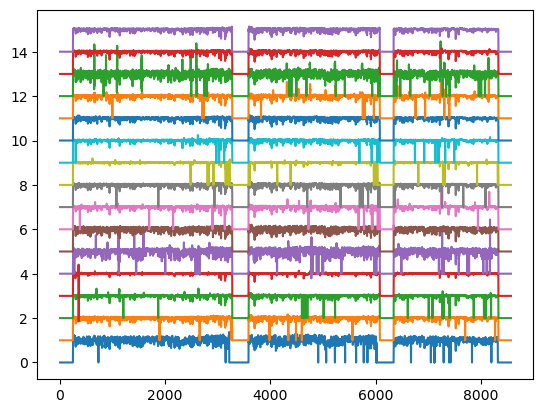

In [107]:
train_features = np.load('./train_features.npy')
train_features = np.float32(train_features)
valid_features = np.load('./valid_features.npy')
test_features = np.load('./test_features.npy')
for i in range(15):
    plt.plot(train_features[i] + i)

In [108]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.input = nn.Linear(input_size, hidden_size)
        self.hidden = nn.Linear(hidden_size, hidden_size)
        self.hidden2 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
        self.activation = nn.LeakyReLU()

    
    def forward(self, x):
        out = self.input(x)
        out = self.activation(out)
        out = self.hidden(out)
        out = self.activation(out)
        out = self.hidden2(out)
        out = self.activation(out)
        out = self.output(out)
        return out

In [109]:
class Dataset(Dataset):

    def __init__(self):
        self.x = torch.from_numpy(train_features)
        self.y = torch.from_numpy(train_labels)
        
        self.x = self.x.unsqueeze(1)  # Make it a column vector
        self.y = self.y.unsqueeze(1)  # Make it a column vector
        print(self.x.shape, self.y.shape)

    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    
dataset_train = Dataset()
dataset_val = Dataset()
train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=32, shuffle=False)

torch.Size([1024, 1, 8575]) torch.Size([1024, 1])
torch.Size([1024, 1, 8575]) torch.Size([1024, 1])


In [114]:
model = MLP(input_size=8575, hidden_size=128, output_size=1)
model(dataset_train[0][0]) 

tensor([[-0.0071]], grad_fn=<AddmmBackward0>)

In [121]:
def run_optimization(num_epochs: int, optimizer, criterion):
    model.train() # Enable dropout, batch norm training mode, etc.
    for epoch in range(num_epochs):
        total_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            output = model(data) # Forward pass
            loss = criterion(output, target) # Compute loss
            
            optimizer.zero_grad()   # Zero gradients from previous step
            loss.backward()         # Backpropagation
            optimizer.step()        # Update weights
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

In [122]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Loss Funciton
criterion = nn.MSELoss()

run_optimization(num_epochs=100, optimizer=optimizer, criterion=criterion)

Epoch 1/100, Loss: 0.4764
Epoch 2/100, Loss: 0.4676
Epoch 3/100, Loss: 0.4724
Epoch 4/100, Loss: 0.4544
Epoch 5/100, Loss: 0.4591
Epoch 6/100, Loss: 0.4603
Epoch 7/100, Loss: 0.4640
Epoch 8/100, Loss: 0.4673
Epoch 9/100, Loss: 0.4657
Epoch 10/100, Loss: 0.4604
Epoch 11/100, Loss: 0.4534
Epoch 12/100, Loss: 0.4661
Epoch 13/100, Loss: 0.4543
Epoch 14/100, Loss: 0.4610
Epoch 15/100, Loss: 0.4593
Epoch 16/100, Loss: 0.4534
Epoch 17/100, Loss: 0.4502
Epoch 18/100, Loss: 0.4548
Epoch 19/100, Loss: 0.4533
Epoch 20/100, Loss: 0.4524
Epoch 21/100, Loss: 0.4659
Epoch 22/100, Loss: 0.4588
Epoch 23/100, Loss: 0.4607
Epoch 24/100, Loss: 0.4622
Epoch 25/100, Loss: 0.4849
Epoch 26/100, Loss: 0.4658
Epoch 27/100, Loss: 0.4553
Epoch 28/100, Loss: 0.4680
Epoch 29/100, Loss: 0.4586
Epoch 30/100, Loss: 0.4628
Epoch 31/100, Loss: 0.4540
Epoch 32/100, Loss: 0.4524
Epoch 33/100, Loss: 0.4517
Epoch 34/100, Loss: 0.4591
Epoch 35/100, Loss: 0.4524
Epoch 36/100, Loss: 0.4635
Epoch 37/100, Loss: 0.4528
Epoch 38/1

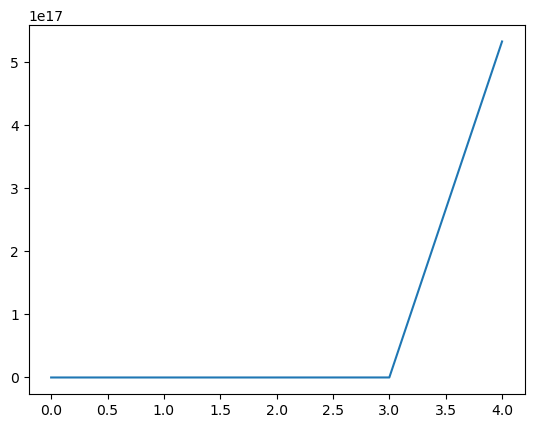

[2.700870990753174, 49633.4296875, 1094618880.0, 24141010829312.0, 5.324121174714614e+17]


In [134]:
data = torch.from_numpy(train_features)

dataA = Variable(torch.from_numpy(train_features)).unsqueeze(1)
y = Variable(torch.from_numpy(train_labels)).unsqueeze(1)

linear = nn.Linear(8575, 1)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)
loss2 = []


for i in range(5):
    optimizer.zero_grad()
    outputs = linear(dataA)
    
    loss = criterion(outputs, y)
    loss2.append(loss.item())
    loss.backward()        

    optimizer.step()
    
plt.plot(range(5), loss2)
plt.show()

print(loss2)